## 01. IMPORT LIBRARIES

In [10]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import (
    RandomForestRegressor,
    RandomForestClassifier,
    GradientBoostingRegressor,
    GradientBoostingClassifier,
    HistGradientBoostingRegressor,
    HistGradientBoostingClassifier
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

from sklearn.utils.class_weight import (
    compute_sample_weight
)


print(
    "Main model development libraries imported successfully."
)

Main model development libraries imported successfully.


## 02. FILE LOCATIONS

In [11]:
PROJECT_ROOT = Path(
    r"C:\Users\bongo\OneDrive\Desktop\GitHub\Movie Analysis Predictor"
)

MODEL_READY_DIR = (
    PROJECT_ROOT
    / "Data"
    / "Model_Ready"
)

FEATURE_DIR = (
    MODEL_READY_DIR
    / "Features"
)

TARGET_DIR = (
    MODEL_READY_DIR
    / "Targets"
)

BASELINE_RESULTS_DIR = (
    PROJECT_ROOT
    / "Data"
    / "Model_Results"
    / "Baseline"
)

RESULTS_OUTPUT_DIR = (
    PROJECT_ROOT
    / "Data"
    / "Model_Results"
    / "Main_Models"
)

MODEL_OUTPUT_DIR = (
    PROJECT_ROOT
    / "Models"
    / "Main_Models"
)

RESULTS_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

MODEL_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Results directory:")
print(RESULTS_OUTPUT_DIR)

print("\nModel directory:")
print(MODEL_OUTPUT_DIR)

Results directory:
C:\Users\bongo\OneDrive\Desktop\GitHub\Movie Analysis Predictor\Data\Model_Results\Main_Models

Model directory:
C:\Users\bongo\OneDrive\Desktop\GitHub\Movie Analysis Predictor\Models\Main_Models


## 03. LOAD MODEL-READY DATA

In [12]:
X_train = pd.read_csv(
    FEATURE_DIR / "X_train.csv"
)

X_validation = pd.read_csv(
    FEATURE_DIR / "X_validation.csv"
)

X_test = pd.read_csv(
    FEATURE_DIR / "X_test.csv"
)


y_train_reg = pd.read_csv(
    TARGET_DIR / "y_train_regression.csv"
)["log_worldwide_box_office"]

y_validation_reg = pd.read_csv(
    TARGET_DIR / "y_validation_regression.csv"
)["log_worldwide_box_office"]

y_test_reg = pd.read_csv(
    TARGET_DIR / "y_test_regression.csv"
)["log_worldwide_box_office"]


y_train_cls = pd.read_csv(
    TARGET_DIR / "y_train_classification.csv"
)["blockbuster"]

y_validation_cls = pd.read_csv(
    TARGET_DIR / "y_validation_classification.csv"
)["blockbuster"]

y_test_cls = pd.read_csv(
    TARGET_DIR / "y_test_classification.csv"
)["blockbuster"]


print("=" * 80)
print("MAIN MODEL DATA")
print("=" * 80)

print("\nTraining:")
print(X_train.shape)

print("\nValidation:")
print(X_validation.shape)

print("\nTest:")
print(X_test.shape)

print(
    "\nTest data loaded for later use, "
    "but will NOT be evaluated in this comparison stage."
)

MAIN MODEL DATA

Training:
(6668, 36)

Validation:
(600, 36)

Test:
(211, 36)

Test data loaded for later use, but will NOT be evaluated in this comparison stage.


## 04. LOAD BASELINE RESULTS

In [13]:
baseline_regression_results = pd.read_csv(
    BASELINE_RESULTS_DIR
    / "regression_baseline_results.csv"
)

baseline_classification_results = pd.read_csv(
    BASELINE_RESULTS_DIR
    / "classification_baseline_results.csv"
)


print("=" * 80)
print("BASELINES LOADED")
print("=" * 80)

print("\nRegression:")
display(baseline_regression_results)

print("\nClassification:")
display(baseline_classification_results)

BASELINES LOADED

Regression:


,model,mae_log,rmse_log,r2,mae_usd,rmse_usd
0,Dummy Regressor,1.909764,2.37789,-0.024839,1.335019e+08,2.789626e+08
1,Ridge Regression,1.135776,1.55364,0.562505,2.253186e+08,1.611513e+09



Classification:


,model,accuracy,precision,recall,f1,roc_auc
0,Dummy Classifier,0.785000,0.000000,0.000000,0.000000,0.50000
1,Logistic Regression,0.781667,0.495652,0.883721,0.635097,0.90673


## 05. EVALUATION FINCTIONS

In [14]:
def evaluate_regression(
    model_name,
    y_true,
    y_pred
):

    return {
        "model": model_name,

        "mae_log": mean_absolute_error(
            y_true,
            y_pred
        ),

        "rmse_log": np.sqrt(
            mean_squared_error(
                y_true,
                y_pred
            )
        ),

        "r2": r2_score(
            y_true,
            y_pred
        )
    }


def evaluate_classification(
    model_name,
    y_true,
    y_pred,
    y_probability
):

    return {
        "model": model_name,

        "accuracy": accuracy_score(
            y_true,
            y_pred
        ),

        "precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "f1": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "roc_auc": roc_auc_score(
            y_true,
            y_probability
        ),

        "average_precision": (
            average_precision_score(
                y_true,
                y_probability
            )
        )
    }


print("Evaluation functions created.")

Evaluation functions created.


## 06. DEFINE REGRESSION MODELS

In [15]:
regression_models = {

    "Random Forest": (
        RandomForestRegressor(
            n_estimators=300,
            max_depth=None,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1
        )
    ),

    "Gradient Boosting": (
        GradientBoostingRegressor(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        )
    ),

    "Hist Gradient Boosting": (
        HistGradientBoostingRegressor(
            learning_rate=0.05,
            max_iter=300,
            max_leaf_nodes=31,
            l2_regularization=1.0,
            random_state=42
        )
    )
}


print("Regression models defined:")

for model_name in regression_models:
    print(f" - {model_name}")

Regression models defined:
 - Random Forest
 - Gradient Boosting
 - Hist Gradient Boosting


## 07. TRAIN AND EVALUATE REGRESSION MODELS

In [16]:
regression_results = []

trained_regression_models = {}


for model_name, model in regression_models.items():

    print(
        f"Training {model_name}..."
    )

    model.fit(
        X_train,
        y_train_reg
    )

    validation_predictions = (
        model.predict(
            X_validation
        )
    )

    result = evaluate_regression(
        model_name,
        y_validation_reg,
        validation_predictions
    )

    regression_results.append(
        result
    )

    trained_regression_models[
        model_name
    ] = model


regression_results = pd.DataFrame(
    regression_results
)


# Add Ridge baseline
ridge_baseline = (
    baseline_regression_results[
        baseline_regression_results[
            "model"
        ] == "Ridge Regression"
    ][
        [
            "model",
            "mae_log",
            "rmse_log",
            "r2"
        ]
    ]
)

regression_comparison = pd.concat(
    [
        ridge_baseline,
        regression_results
    ],
    ignore_index=True
)


regression_comparison = (
    regression_comparison
    .sort_values(
        "rmse_log",
        ascending=True
    )
    .reset_index(drop=True)
)


print("=" * 80)
print("REGRESSION MODEL COMPARISON")
print("=" * 80)

display(
    regression_comparison
)

Training Random Forest...
Training Gradient Boosting...
Training Hist Gradient Boosting...


c:\Users\bongo\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\bongo\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\bongo\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\bongo\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

REGRESSION MODEL COMPARISON


,model,mae_log,rmse_log,r2
0,Hist Gradient Boosting,1.023664,1.416191,0.636490
1,Random Forest,1.039830,1.455216,0.616180
2,Gradient Boosting,1.062947,1.470227,0.608221
3,Ridge Regression,1.135776,1.553640,0.562505


## 7A. REDISPLAY REGRESSION COMPARISON

In [17]:
display(
    regression_comparison
)

,model,mae_log,rmse_log,r2
0,Hist Gradient Boosting,1.023664,1.416191,0.636490
1,Random Forest,1.039830,1.455216,0.616180
2,Gradient Boosting,1.062947,1.470227,0.608221
3,Ridge Regression,1.135776,1.553640,0.562505


## 08. DEFINE CLASSIFICATION MODELS

In [18]:
classification_models = {

    "Random Forest": (
        RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )
    ),

    "Gradient Boosting": (
        GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        )
    ),

    "Hist Gradient Boosting": (
        HistGradientBoostingClassifier(
            learning_rate=0.05,
            max_iter=300,
            max_leaf_nodes=31,
            l2_regularization=1.0,
            random_state=42
        )
    )
}


print("Classification models defined:")

for model_name in classification_models:
    print(f" - {model_name}")

Classification models defined:
 - Random Forest
 - Gradient Boosting
 - Hist Gradient Boosting


## 09. CLASSIFICATION SAMPLE WEIGHTS

In [10]:
classification_sample_weights = (
    compute_sample_weight(
        class_weight="balanced",
        y=y_train_cls
    )
)


print("=" * 80)
print("CLASSIFICATION SAMPLE WEIGHTS")
print("=" * 80)

print(
    f"\nNumber of weights: "
    f"{len(classification_sample_weights):,}"
)

print(
    f"Minimum weight: "
    f"{classification_sample_weights.min():.3f}"
)

print(
    f"Maximum weight: "
    f"{classification_sample_weights.max():.3f}"
)

CLASSIFICATION SAMPLE WEIGHTS

Number of weights: 6,668
Minimum weight: 0.556
Maximum weight: 4.999


## 10. TRAIN AND EVLUATE CLASSIFICATION MODELS

In [11]:
classification_results = []

trained_classification_models = {}


for model_name, model in classification_models.items():

    print(
        f"Training {model_name}..."
    )

    if model_name == "Random Forest":

        # Random Forest already uses class_weight="balanced"
        model.fit(
            X_train,
            y_train_cls
        )

    else:

        model.fit(
            X_train,
            y_train_cls,
            sample_weight=classification_sample_weights
        )


    validation_predictions = (
        model.predict(
            X_validation
        )
    )

    validation_probabilities = (
        model.predict_proba(
            X_validation
        )[:, 1]
    )


    result = evaluate_classification(
        model_name,
        y_validation_cls,
        validation_predictions,
        validation_probabilities
    )

    classification_results.append(
        result
    )

    trained_classification_models[
        model_name
    ] = model


classification_results = pd.DataFrame(
    classification_results
)


# ------------------------------------------------------------
# Add Logistic Regression baseline
# ------------------------------------------------------------

logistic_baseline = (
    baseline_classification_results[
        baseline_classification_results[
            "model"
        ] == "Logistic Regression"
    ]
    .copy()
)

if (
    "average_precision"
    not in logistic_baseline.columns
):

    logistic_baseline[
        "average_precision"
    ] = np.nan


classification_comparison = pd.concat(
    [
        logistic_baseline[
            [
                "model",
                "accuracy",
                "precision",
                "recall",
                "f1",
                "roc_auc",
                "average_precision"
            ]
        ],

        classification_results
    ],
    ignore_index=True
)


classification_comparison = (
    classification_comparison
    .sort_values(
        "roc_auc",
        ascending=False
    )
    .reset_index(drop=True)
)


print("=" * 80)
print("CLASSIFICATION MODEL COMPARISON")
print("=" * 80)

display(
    classification_comparison
)

Training Random Forest...
Training Gradient Boosting...
Training Hist Gradient Boosting...
CLASSIFICATION MODEL COMPARISON


,model,accuracy,precision,recall,f1,roc_auc,average_precision
0,Random Forest,0.883333,0.761062,0.666667,0.710744,0.913247,0.805554
1,Gradient Boosting,0.820000,0.553299,0.844961,0.668712,0.911848,0.806258
2,Logistic Regression,0.781667,0.495652,0.883721,0.635097,0.906730,NaN
3,Hist Gradient Boosting,0.865000,0.666667,0.744186,0.703297,0.900821,0.790419


## 11. REGRESSION COMPARISON VISUAL

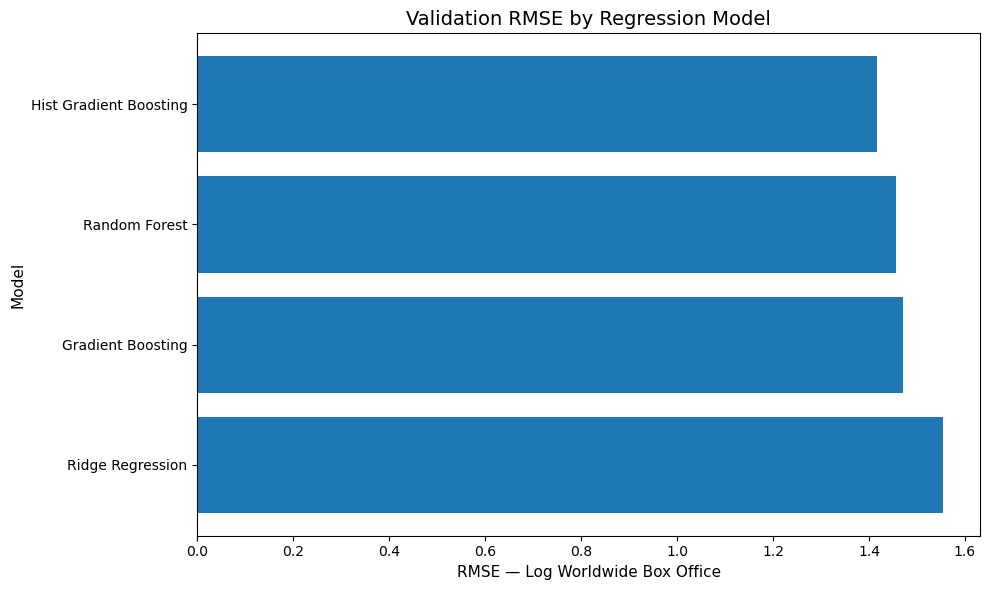

In [12]:
plot_data = (
    regression_comparison
    .sort_values(
        "rmse_log",
        ascending=False
    )
)


fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.barh(
    plot_data["model"],
    plot_data["rmse_log"]
)

ax.set_title(
    "Validation RMSE by Regression Model",
    fontsize=14
)

ax.set_xlabel(
    "RMSE — Log Worldwide Box Office",
    fontsize=11
)

ax.set_ylabel(
    "Model",
    fontsize=11
)

plt.tight_layout()
plt.show()

## 12. CLASSIFICATION COMPARISON VISUAL

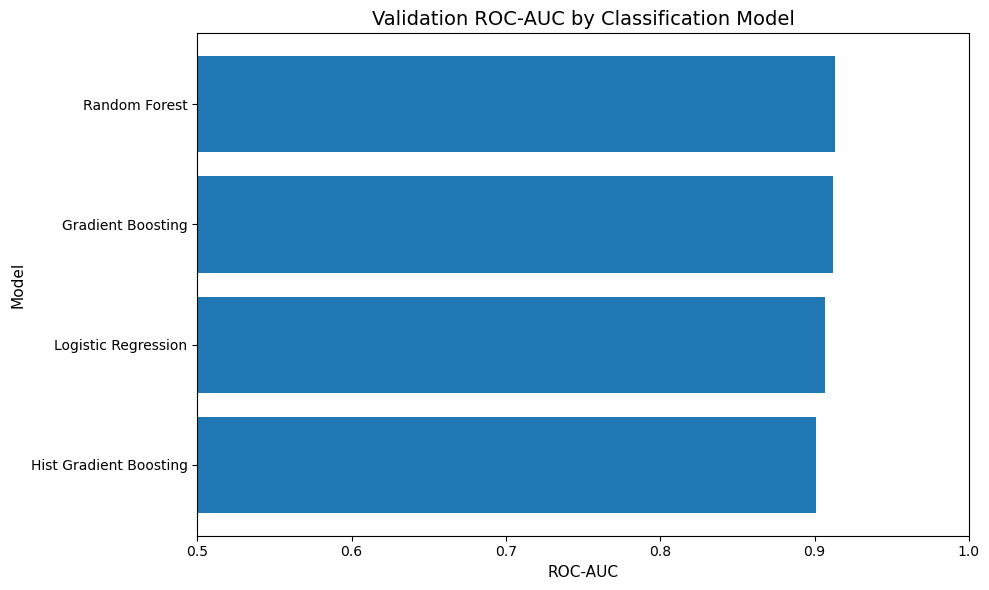

In [13]:
plot_data = (
    classification_comparison
    .sort_values(
        "roc_auc",
        ascending=True
    )
)


fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.barh(
    plot_data["model"],
    plot_data["roc_auc"]
)

ax.set_title(
    "Validation ROC-AUC by Classification Model",
    fontsize=14
)

ax.set_xlabel(
    "ROC-AUC",
    fontsize=11
)

ax.set_ylabel(
    "Model",
    fontsize=11
)

ax.set_xlim(
    0.5,
    1.0
)

plt.tight_layout()
plt.show()

## 13. DEFINE TUNING GRIDS

In [19]:
from sklearn.model_selection import ParameterGrid


# ------------------------------------------------------------
# Hist Gradient Boosting Regressor
# ------------------------------------------------------------

regression_tuning_grid = {

    "learning_rate": [
        0.03,
        0.05
    ],

    "max_iter": [
        250,
        350
    ],

    "max_leaf_nodes": [
        15,
        31,
        63
    ],

    "min_samples_leaf": [
        10,
        20
    ],

    "l2_regularization": [
        1.0
    ]
}


# ------------------------------------------------------------
# Random Forest Classifier
# ------------------------------------------------------------

classification_tuning_grid = {

    "n_estimators": [
        300,
        500
    ],

    "max_depth": [
        None,
        16,
        24
    ],

    "min_samples_leaf": [
        1,
        2,
        4
    ],

    "max_features": [
        "sqrt"
    ]
}


regression_parameter_sets = list(
    ParameterGrid(
        regression_tuning_grid
    )
)

classification_parameter_sets = list(
    ParameterGrid(
        classification_tuning_grid
    )
)


print("=" * 80)
print("TUNING CONFIGURATION")
print("=" * 80)

print(
    f"\nRegression configurations: "
    f"{len(regression_parameter_sets)}"
)

print(
    f"Classification configurations: "
    f"{len(classification_parameter_sets)}"
)

print(
    "\nThe chronological validation set "
    "will be used for model selection."
)

print(
    "The test set remains untouched."
)

TUNING CONFIGURATION

Regression configurations: 24
Classification configurations: 18

The chronological validation set will be used for model selection.
The test set remains untouched.


## 14. TUNE HIST GRADIENT BOOSTING REGRESSOR

In [20]:
regression_tuning_results = []

best_regression_model = None
best_regression_params = None
best_regression_rmse = np.inf


for i, params in enumerate(
    regression_parameter_sets,
    start=1
):

    model = HistGradientBoostingRegressor(
        **params,
        early_stopping=False,
        random_state=42
    )

    model.fit(
        X_train,
        y_train_reg
    )

    validation_predictions = (
        model.predict(
            X_validation
        )
    )

    result = evaluate_regression(
        "Hist Gradient Boosting",
        y_validation_reg,
        validation_predictions
    )

    result.update(params)

    regression_tuning_results.append(
        result
    )


    if result["rmse_log"] < best_regression_rmse:

        best_regression_rmse = (
            result["rmse_log"]
        )

        best_regression_model = model

        best_regression_params = (
            params.copy()
        )


regression_tuning_results = pd.DataFrame(
    regression_tuning_results
)

regression_tuning_results = (
    regression_tuning_results
    .sort_values(
        "rmse_log"
    )
    .reset_index(drop=True)
)


print("=" * 80)
print("REGRESSION TUNING COMPLETE")
print("=" * 80)

print("\nBest parameters:")

for key, value in best_regression_params.items():
    print(f"{key}: {value}")


print(
    f"\nBest validation RMSE: "
    f"{best_regression_rmse:.6f}"
)


print("\nTop 5 configurations:")

display(
    regression_tuning_results.head(5)
)

REGRESSION TUNING COMPLETE

Best parameters:
l2_regularization: 1.0
learning_rate: 0.05
max_iter: 250
max_leaf_nodes: 31
min_samples_leaf: 20

Best validation RMSE: 1.414490

Top 5 configurations:


,model,mae_log,rmse_log,r2,l2_regularization,learning_rate,max_iter,max_leaf_nodes,min_samples_leaf
0,Hist Gradient Boosting,1.022446,1.414490,0.637363,1.0,0.05,250,31,20
1,Hist Gradient Boosting,1.028079,1.417373,0.635884,1.0,0.03,250,63,20
2,Hist Gradient Boosting,1.024249,1.417789,0.635670,1.0,0.05,350,31,20
3,Hist Gradient Boosting,1.033781,1.422497,0.633246,1.0,0.03,350,63,20
4,Hist Gradient Boosting,1.029495,1.426234,0.631317,1.0,0.03,350,31,20


## 15. TUNE RANDOM FOREST CLASSIFIER

In [21]:
classification_tuning_results = []

best_classification_model = None
best_classification_params = None
best_classification_auc = -np.inf


for i, params in enumerate(
    classification_parameter_sets,
    start=1
):

    model = RandomForestClassifier(
        **params,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train,
        y_train_cls
    )


    validation_predictions = (
        model.predict(
            X_validation
        )
    )

    validation_probabilities = (
        model.predict_proba(
            X_validation
        )[:, 1]
    )


    result = evaluate_classification(
        "Random Forest",
        y_validation_cls,
        validation_predictions,
        validation_probabilities
    )

    result.update(params)

    classification_tuning_results.append(
        result
    )


    if result["roc_auc"] > best_classification_auc:

        best_classification_auc = (
            result["roc_auc"]
        )

        best_classification_model = model

        best_classification_params = (
            params.copy()
        )


classification_tuning_results = pd.DataFrame(
    classification_tuning_results
)

classification_tuning_results = (
    classification_tuning_results
    .sort_values(
        "roc_auc",
        ascending=False
    )
    .reset_index(drop=True)
)


print("=" * 80)
print("CLASSIFICATION TUNING COMPLETE")
print("=" * 80)

print("\nBest parameters:")

for key, value in best_classification_params.items():
    print(f"{key}: {value}")


print(
    f"\nBest validation ROC-AUC: "
    f"{best_classification_auc:.6f}"
)


print("\nTop 5 configurations:")

display(
    classification_tuning_results.head(5)
)

CLASSIFICATION TUNING COMPLETE

Best parameters:
max_depth: None
max_features: sqrt
min_samples_leaf: 4
n_estimators: 500

Best validation ROC-AUC: 0.915272

Top 5 configurations:


,model,accuracy,precision,recall,f1,roc_auc,average_precision,max_depth,max_features,min_samples_leaf,n_estimators
0,Random Forest,0.876667,0.700730,0.744186,0.721805,0.915272,0.808715,NaN,sqrt,4,500
1,Random Forest,0.883333,0.712230,0.767442,0.738806,0.915124,0.808457,16.0,sqrt,4,500
2,Random Forest,0.878333,0.705882,0.744186,0.724528,0.915058,0.808137,24.0,sqrt,4,500
3,Random Forest,0.870000,0.680851,0.744186,0.711111,0.914811,0.809917,NaN,sqrt,4,300
4,Random Forest,0.871667,0.685714,0.744186,0.713755,0.914712,0.808691,24.0,sqrt,4,300


## 16. TUNED VS. UNTUNED MODEL COMPARISON

In [23]:
# ============================================================
# CELL 16: TUNED VS UNTUNED MODEL COMPARISON
# ============================================================

# ------------------------------------------------------------
# Recreate ORIGINAL Hist Gradient Boosting Regressor
# ------------------------------------------------------------

original_regression_model = (
    HistGradientBoostingRegressor(
        learning_rate=0.05,
        max_iter=300,
        max_leaf_nodes=31,
        l2_regularization=1.0,
        random_state=42
    )
)

original_regression_model.fit(
    X_train,
    y_train_reg
)

original_regression_predictions = (
    original_regression_model.predict(
        X_validation
    )
)

original_regression_result = (
    evaluate_regression(
        "Original Hist Gradient Boosting",
        y_validation_reg,
        original_regression_predictions
    )
)


# ------------------------------------------------------------
# Evaluate TUNED Hist Gradient Boosting Regressor
# ------------------------------------------------------------

tuned_regression_predictions = (
    best_regression_model.predict(
        X_validation
    )
)

tuned_regression_result = (
    evaluate_regression(
        "Tuned Hist Gradient Boosting",
        y_validation_reg,
        tuned_regression_predictions
    )
)


regression_tuning_comparison = pd.DataFrame({

    "version": [
        "Original",
        "Tuned"
    ],

    "mae_log": [
        original_regression_result["mae_log"],
        tuned_regression_result["mae_log"]
    ],

    "rmse_log": [
        original_regression_result["rmse_log"],
        tuned_regression_result["rmse_log"]
    ],

    "r2": [
        original_regression_result["r2"],
        tuned_regression_result["r2"]
    ]
})


# ------------------------------------------------------------
# Recreate ORIGINAL Random Forest Classifier
# ------------------------------------------------------------

original_classification_model = (
    RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
)

original_classification_model.fit(
    X_train,
    y_train_cls
)

original_classification_predictions = (
    original_classification_model.predict(
        X_validation
    )
)

original_classification_probabilities = (
    original_classification_model.predict_proba(
        X_validation
    )[:, 1]
)

original_classification_result = (
    evaluate_classification(
        "Original Random Forest",
        y_validation_cls,
        original_classification_predictions,
        original_classification_probabilities
    )
)


# ------------------------------------------------------------
# Evaluate TUNED Random Forest Classifier
# ------------------------------------------------------------

tuned_classification_predictions = (
    best_classification_model.predict(
        X_validation
    )
)

tuned_classification_probabilities = (
    best_classification_model.predict_proba(
        X_validation
    )[:, 1]
)

tuned_classification_result = (
    evaluate_classification(
        "Tuned Random Forest",
        y_validation_cls,
        tuned_classification_predictions,
        tuned_classification_probabilities
    )
)


classification_tuning_comparison = pd.DataFrame({

    "version": [
        "Original",
        "Tuned"
    ],

    "accuracy": [
        original_classification_result["accuracy"],
        tuned_classification_result["accuracy"]
    ],

    "precision": [
        original_classification_result["precision"],
        tuned_classification_result["precision"]
    ],

    "recall": [
        original_classification_result["recall"],
        tuned_classification_result["recall"]
    ],

    "f1": [
        original_classification_result["f1"],
        tuned_classification_result["f1"]
    ],

    "roc_auc": [
        original_classification_result["roc_auc"],
        tuned_classification_result["roc_auc"]
    ],

    "average_precision": [
        original_classification_result[
            "average_precision"
        ],
        tuned_classification_result[
            "average_precision"
        ]
    ]
})


print("=" * 80)
print("REGRESSION — ORIGINAL VS TUNED")
print("=" * 80)

display(
    regression_tuning_comparison
)


print("\n" + "=" * 80)
print("CLASSIFICATION — ORIGINAL VS TUNED")
print("=" * 80)

display(
    classification_tuning_comparison
)

REGRESSION — ORIGINAL VS TUNED


,version,mae_log,rmse_log,r2
0,Original,1.023664,1.416191,0.636490
1,Tuned,1.022446,1.414490,0.637363



CLASSIFICATION — ORIGINAL VS TUNED


,version,accuracy,precision,recall,f1,roc_auc,average_precision
0,Original,0.883333,0.761062,0.666667,0.710744,0.913247,0.805554
1,Tuned,0.876667,0.700730,0.744186,0.721805,0.915272,0.808715


## 17. CLASSIFICATION THRESHOLD SELECTION

In [24]:
selected_classifier = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    max_features="sqrt",
    min_samples_leaf=4,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

selected_classifier.fit(
    X_train,
    y_train_cls
)


# ------------------------------------------------------------
# Validation probabilities
# ------------------------------------------------------------

validation_probabilities = (
    selected_classifier.predict_proba(
        X_validation
    )[:, 1]
)


# ------------------------------------------------------------
# Test possible probability thresholds
# ------------------------------------------------------------

threshold_results = []

for threshold in np.arange(
    0.10,
    0.91,
    0.01
):

    predictions = (
        validation_probabilities
        >= threshold
    ).astype(int)

    threshold_results.append({

        "threshold": threshold,

        "accuracy": accuracy_score(
            y_validation_cls,
            predictions
        ),

        "precision": precision_score(
            y_validation_cls,
            predictions,
            zero_division=0
        ),

        "recall": recall_score(
            y_validation_cls,
            predictions,
            zero_division=0
        ),

        "f1": f1_score(
            y_validation_cls,
            predictions,
            zero_division=0
        )
    })


threshold_results = pd.DataFrame(
    threshold_results
)


# ------------------------------------------------------------
# Select threshold with highest validation F1
# ------------------------------------------------------------

threshold_results = (
    threshold_results
    .sort_values(
        [
            "f1",
            "recall"
        ],
        ascending=[
            False,
            False
        ]
    )
    .reset_index(drop=True)
)


best_threshold = float(
    threshold_results.iloc[0][
        "threshold"
    ]
)


print("=" * 80)
print("CLASSIFICATION THRESHOLD SELECTION")
print("=" * 80)

print(
    f"\nSelected threshold: "
    f"{best_threshold:.2f}"
)

print("\nBest validation performance:")

display(
    threshold_results.head(1)
)

print("\nTop 10 thresholds:")

display(
    threshold_results.head(10)
)

CLASSIFICATION THRESHOLD SELECTION

Selected threshold: 0.57

Best validation performance:


,threshold,accuracy,precision,recall,f1
0,0.57,0.888333,0.75,0.72093,0.735178



Top 10 thresholds:


,threshold,accuracy,precision,recall,f1
0,0.57,0.888333,0.750000,0.720930,0.735178
1,0.55,0.885000,0.730769,0.736434,0.733591
2,0.62,0.890000,0.773913,0.689922,0.729508
3,0.56,0.885000,0.738095,0.720930,0.729412
4,0.58,0.886667,0.752066,0.705426,0.728000
5,0.61,0.888333,0.767241,0.689922,0.726531
6,0.60,0.886667,0.756303,0.697674,0.725806
7,0.52,0.880000,0.714286,0.736434,0.725191
8,0.53,0.880000,0.714286,0.736434,0.725191
9,0.54,0.880000,0.714286,0.736434,0.725191


## 18. LOCK FINAL MODEL COMFIGURATION

In [26]:
selected_regression_params = {

    "l2_regularization": 1.0,
    "learning_rate": 0.05,
    "max_iter": 250,
    "max_leaf_nodes": 31,
    "min_samples_leaf": 20
}


selected_classification_params = {

    "n_estimators": 500,
    "max_depth": None,
    "max_features": "sqrt",
    "min_samples_leaf": 4,
    "class_weight": "balanced"
}


final_model_selection = pd.DataFrame({

    "task": [
        "Worldwide Box Office Regression",
        "Blockbuster Classification"
    ],

    "selected_model": [
        "Hist Gradient Boosting",
        "Random Forest"
    ],

    "primary_validation_metric": [
        "RMSE = 1.414490",
        "ROC-AUC = 0.915272"
    ],

    "additional_validation_metric": [
        "R² = 0.637363",
        "F1 = 0.721805 at default threshold"
    ]
})


print("=" * 80)
print("FINAL MODEL CONFIGURATION LOCKED")
print("=" * 80)

display(
    final_model_selection
)

print(
    f"\nClassification decision threshold: "
    f"{best_threshold:.2f}"
)

print(
    "\nThe test set has still not been evaluated."
)

FINAL MODEL CONFIGURATION LOCKED


,task,selected_model,primary_validation_metric,additional_validation_metric
0,Worldwide Box Office Regression,Hist Gradient Boosting,RMSE = 1.414490,R² = 0.637363
1,Blockbuster Classification,Random Forest,ROC-AUC = 0.915272,F1 = 0.721805 at default threshold



Classification decision threshold: 0.57

The test set has still not been evaluated.


## 19. DEFERRED GENRE RECONCILIATION AUDIT

In [27]:
import re
import unicodedata


CLEANED_MOVIES_PATH = (
    PROJECT_ROOT
    / "Data"
    / "Clean"
    / "cleaned_movies.csv"
)

HISTORICAL_FEATURES_PATH = (
    PROJECT_ROOT
    / "Data"
    / "Features"
    / "historical_model_features.csv"
)


cleaned_movies = pd.read_csv(
    CLEANED_MOVIES_PATH
)

historical_features = pd.read_csv(
    HISTORICAL_FEATURES_PATH
)


# ------------------------------------------------------------
# Normalise titles for matching
# ------------------------------------------------------------

def normalize_title(value):

    if pd.isna(value):
        return ""

    value = str(value)

    value = unicodedata.normalize(
        "NFKD",
        value
    )

    value = (
        value
        .encode(
            "ascii",
            "ignore"
        )
        .decode("ascii")
    )

    value = value.lower().strip()

    value = re.sub(
        r"[^a-z0-9]+",
        " ",
        value
    )

    value = re.sub(
        r"\s+",
        " ",
        value
    )

    return value.strip()


# ------------------------------------------------------------
# Compare genre sets
# ------------------------------------------------------------

source_genres = set(
    cleaned_movies["genre"]
    .dropna()
    .astype(str)
    .str.strip()
    .unique()
)

historical_genres = set(
    historical_features["primary_genre"]
    .dropna()
    .astype(str)
    .str.strip()
    .unique()
)


missing_from_historical = sorted(
    source_genres
    - historical_genres
)

extra_in_historical = sorted(
    historical_genres
    - source_genres
)


print("=" * 80)
print("GENRE RECONCILIATION AUDIT")
print("=" * 80)

print(
    f"\nGenres in cleaned source: "
    f"{len(source_genres)}"
)

print(
    f"Genres in historical model data: "
    f"{len(historical_genres)}"
)

print(
    "\nGenre(s) present upstream "
    "but absent from model data:"
)

print(
    missing_from_historical
)

print(
    "\nUnexpected genres in model data:"
)

print(
    extra_in_historical
)


# ------------------------------------------------------------
# Investigate only the missing genre rows
# ------------------------------------------------------------

if missing_from_historical:

    missing_genre_rows = (
        cleaned_movies[
            cleaned_movies["genre"]
            .astype(str)
            .str.strip()
            .isin(
                missing_from_historical
            )
        ][
            [
                "name",
                "year",
                "genre",
                "gross",
                "budget"
            ]
        ]
        .copy()
    )

    print(
        "\nMovies belonging to the "
        "missing genre(s):"
    )

    display(
        missing_genre_rows
    )

    print(
        "\nMissing genre row count:"
    )

    display(
        missing_genre_rows[
            "genre"
        ]
        .value_counts()
        .rename_axis("genre")
        .reset_index(
            name="source_rows"
        )
    )

GENRE RECONCILIATION AUDIT

Genres in cleaned source: 19
Genres in historical model data: 18

Genre(s) present upstream but absent from model data:
['History']

Unexpected genres in model data:
[]

Movies belonging to the missing genre(s):


,name,year,genre,gross,budget
474,The Business of Show Business,1983,History,NaN,323562.0



Missing genre row count:


,genre,source_rows
0,History,1


### Genre Reconciliation Conclusion

The cleaned source contains 19 genres, while the supervised historical
modelling dataset contains 18.

The only genre absent from the modelling dataset is `History`. Its sole
source record, *The Business of Show Business* (1983), has no reported
worldwide box-office gross.

Because worldwide box office is required to construct both the regression
and classification targets, this record is not eligible for supervised
modelling.

Therefore, the 18-genre modelling dataset is valid and no feature-engineering
correction is required.

## 20. REFIT LOCKED MODELS ON TRAIN+VALIDATION

In [28]:
X_train_final = pd.concat(
    [
        X_train,
        X_validation
    ],
    axis=0,
    ignore_index=True
)

y_train_reg_final = pd.concat(
    [
        y_train_reg,
        y_validation_reg
    ],
    axis=0,
    ignore_index=True
)

y_train_cls_final = pd.concat(
    [
        y_train_cls,
        y_validation_cls
    ],
    axis=0,
    ignore_index=True
)


# ------------------------------------------------------------
# Final locked regression model
# ------------------------------------------------------------

final_regression_model = (
    HistGradientBoostingRegressor(
        l2_regularization=1.0,
        learning_rate=0.05,
        max_iter=250,
        max_leaf_nodes=31,
        min_samples_leaf=20,
        early_stopping=False,
        random_state=42
    )
)

final_regression_model.fit(
    X_train_final,
    y_train_reg_final
)


# ------------------------------------------------------------
# Final locked classification model
# ------------------------------------------------------------

final_classification_model = (
    RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        max_features="sqrt",
        min_samples_leaf=4,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
)

final_classification_model.fit(
    X_train_final,
    y_train_cls_final
)


FINAL_CLASSIFICATION_THRESHOLD = 0.57


print("=" * 80)
print("FINAL MODELS REFITTED")
print("=" * 80)

print(
    f"\nTraining observations: "
    f"{len(X_train_final):,}"
)

print(
    f"Test observations: "
    f"{len(X_test):,}"
)

print(
    "\nRegression model: "
    "Hist Gradient Boosting"
)

print(
    "Classification model: "
    "Random Forest"
)

print(
    f"Classification threshold: "
    f"{FINAL_CLASSIFICATION_THRESHOLD:.2f}"
)

print(
    "\nModel configurations are locked."
)

FINAL MODELS REFITTED

Training observations: 7,268
Test observations: 211

Regression model: Hist Gradient Boosting
Classification model: Random Forest
Classification threshold: 0.57

Model configurations are locked.


## 21. FINAL TEST SET EVALUATION

In [29]:
test_regression_predictions = (
    final_regression_model.predict(
        X_test
    )
)


final_regression_test_results = pd.DataFrame([
    evaluate_regression(
        "Hist Gradient Boosting",
        y_test_reg,
        test_regression_predictions
    )
])


# ------------------------------------------------------------
# Classification probabilities
# ------------------------------------------------------------

test_classification_probabilities = (
    final_classification_model.predict_proba(
        X_test
    )[:, 1]
)


# Apply locked validation-derived threshold
test_classification_predictions = (
    test_classification_probabilities
    >= FINAL_CLASSIFICATION_THRESHOLD
).astype(int)


final_classification_test_results = pd.DataFrame([
    evaluate_classification(
        "Random Forest",
        y_test_cls,
        test_classification_predictions,
        test_classification_probabilities
    )
])


# ------------------------------------------------------------
# Confusion matrix
# ------------------------------------------------------------

from sklearn.metrics import confusion_matrix


final_test_confusion_matrix = (
    confusion_matrix(
        y_test_cls,
        test_classification_predictions
    )
)


final_test_confusion_matrix_df = (
    pd.DataFrame(
        final_test_confusion_matrix,
        index=[
            "Actual Non-Blockbuster",
            "Actual Blockbuster"
        ],
        columns=[
            "Predicted Non-Blockbuster",
            "Predicted Blockbuster"
        ]
    )
)


# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("=" * 80)
print("FINAL REGRESSION TEST RESULTS")
print("=" * 80)

display(
    final_regression_test_results
)


print("\n" + "=" * 80)
print("FINAL CLASSIFICATION TEST RESULTS")
print("=" * 80)

display(
    final_classification_test_results
)


print("\n" + "=" * 80)
print("FINAL CLASSIFICATION CONFUSION MATRIX")
print("=" * 80)

display(
    final_test_confusion_matrix_df
)


print(
    "\nIMPORTANT: Test evaluation is complete. "
    "Do not tune model parameters or the classification "
    "threshold using these results."
)

FINAL REGRESSION TEST RESULTS


,model,mae_log,rmse_log,r2
0,Hist Gradient Boosting,1.377432,1.93482,0.574359



FINAL CLASSIFICATION TEST RESULTS


,model,accuracy,precision,recall,f1,roc_auc,average_precision
0,Random Forest,0.872038,0.780488,0.64,0.703297,0.908944,0.824084



FINAL CLASSIFICATION CONFUSION MATRIX


,Predicted Non-Blockbuster,Predicted Blockbuster
Actual Non-Blockbuster,152,9
Actual Blockbuster,18,32



IMPORTANT: Test evaluation is complete. Do not tune model parameters or the classification threshold using these results.


## 22. SAVE FINAL MODEL AND TEST RESULTS

In [ ]:
FINAL_MODEL_DIR = (
    PROJECT_ROOT
    / "Models"
    / "Final"
)

FINAL_RESULTS_DIR = (
    PROJECT_ROOT
    / "Data"
    / "Model_Results"
    / "Final"
)

FINAL_MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FINAL_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# Save models
# ------------------------------------------------------------

joblib.dump(
    final_regression_model,
    FINAL_MODEL_DIR
    / "final_hist_gradient_boosting_regressor.joblib"
)

joblib.dump(
    final_classification_model,
    FINAL_MODEL_DIR
    / "final_random_forest_classifier.joblib"
)


# ------------------------------------------------------------
# Save test results
# ------------------------------------------------------------

final_regression_test_results.to_csv(
    FINAL_RESULTS_DIR
    / "final_regression_test_results.csv",
    index=False
)

final_classification_test_results.to_csv(
    FINAL_RESULTS_DIR
    / "final_classification_test_results.csv",
    index=False
)

final_test_confusion_matrix_df.to_csv(
    FINAL_RESULTS_DIR
    / "final_classification_confusion_matrix.csv"
)


print("=" * 80)
print("FINAL MODELS AND RESULTS SAVED")
print("=" * 80)

print("\nModels:")
print(FINAL_MODEL_DIR)

print("\nResults:")
print(FINAL_RESULTS_DIR)

FINAL MODELS AND RESULTS SAVED

Models:
C:\Users\bongo\OneDrive\Desktop\GitHub\Movie Analysis Predictor\Models\Final

Results:
C:\Users\bongo\OneDrive\Desktop\GitHub\Movie Analysis Predictor\Data\Model_Results\Final


## 23. SAVE FINAL MODEL METADATA

In [31]:
import json


final_model_metadata = {

    "regression": {

        "model":
            "HistGradientBoostingRegressor",

        "parameters":
            selected_regression_params,

        "validation_rmse_log":
            1.414490,

        "validation_r2":
            0.637363,

        "test_mae_log":
            float(
                final_regression_test_results.loc[
                    0,
                    "mae_log"
                ]
            ),

        "test_rmse_log":
            float(
                final_regression_test_results.loc[
                    0,
                    "rmse_log"
                ]
            ),

        "test_r2":
            float(
                final_regression_test_results.loc[
                    0,
                    "r2"
                ]
            )
    },


    "classification": {

        "model":
            "RandomForestClassifier",

        "parameters":
            selected_classification_params,

        "decision_threshold":
            FINAL_CLASSIFICATION_THRESHOLD,

        "validation_roc_auc":
            0.915272,

        "validation_f1_at_selected_threshold":
            0.735178,

        "test_accuracy":
            float(
                final_classification_test_results.loc[
                    0,
                    "accuracy"
                ]
            ),

        "test_precision":
            float(
                final_classification_test_results.loc[
                    0,
                    "precision"
                ]
            ),

        "test_recall":
            float(
                final_classification_test_results.loc[
                    0,
                    "recall"
                ]
            ),

        "test_f1":
            float(
                final_classification_test_results.loc[
                    0,
                    "f1"
                ]
            ),

        "test_roc_auc":
            float(
                final_classification_test_results.loc[
                    0,
                    "roc_auc"
                ]
            ),

        "test_average_precision":
            float(
                final_classification_test_results.loc[
                    0,
                    "average_precision"
                ]
            )
    },


    "test_policy": (
        "Test set evaluated once after model selection, "
        "hyperparameter tuning and threshold selection."
    ),

    "genre_reconciliation": (
        "19 genres exist in the cleaned source, but History "
        "contains only one movie with missing worldwide gross. "
        "The supervised modelling dataset therefore correctly "
        "contains 18 eligible genres."
    )
}


metadata_path = (
    FINAL_RESULTS_DIR
    / "final_model_metadata.json"
)


with open(
    metadata_path,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        final_model_metadata,
        file,
        indent=4
    )


print("=" * 80)
print("FINAL MODEL METADATA SAVED")
print("=" * 80)

print(metadata_path)

FINAL MODEL METADATA SAVED
C:\Users\bongo\OneDrive\Desktop\GitHub\Movie Analysis Predictor\Data\Model_Results\Final\final_model_metadata.json


## 24. FINAL NOTEBOOK SUMMARY

In [32]:
final_summary = pd.DataFrame({

    "item": [

        "Regression Model",

        "Regression Validation RMSE",

        "Regression Test RMSE",

        "Regression Test R²",

        "Classification Model",

        "Classification Threshold",

        "Classification Validation ROC-AUC",

        "Classification Test ROC-AUC",

        "Classification Test Precision",

        "Classification Test Recall",

        "Classification Test F1",

        "Genre Reconciliation",

        "Test Set Policy"
    ],

    "result": [

        "Hist Gradient Boosting",

        "1.414490",

        "1.934820",

        "0.574359",

        "Random Forest",

        "0.57",

        "0.915272",

        "0.908944",

        "0.780488",

        "0.640000",

        "0.703297",

        (
            "18 eligible modelling genres confirmed; "
            "History excluded because its sole source "
            "record has no worldwide gross"
        ),

        (
            "Evaluated once after all modelling "
            "decisions were locked"
        )
    ]
})


print("=" * 80)
print("MAIN MODEL DEVELOPMENT AND COMPARISON — COMPLETE")
print("=" * 80)

display(
    final_summary
)


print(
    "\nSTATUS: DELIVERABLE 08 COMPLETE."
)

print(
    "\nRegression final model: "
    "Hist Gradient Boosting"
)

print(
    "Classification final model: "
    "Random Forest"
)

print(
    "\nNo further tuning should be performed "
    "using the test results."
)

MAIN MODEL DEVELOPMENT AND COMPARISON — COMPLETE


,item,result
0,Regression Model,Hist Gradient Boosting
1,Regression Validation RMSE,1.414490
2,Regression Test RMSE,1.934820
3,Regression Test R²,0.574359
4,Classification Model,Random Forest
5,Classification Threshold,0.57
6,Classification Validation ROC-AUC,0.915272
7,Classification Test ROC-AUC,0.908944
8,Classification Test Precision,0.780488
9,Classification Test Recall,0.640000



STATUS: DELIVERABLE 08 COMPLETE.

Regression final model: Hist Gradient Boosting
Classification final model: Random Forest

No further tuning should be performed using the test results.
